`[Homework] Предсказание разрушение портала`

**Цель:** Разработать модель машинного обучения для предсказания значения переменной `Гармония Бессмертия`, которая является ключевым показателем стабильности магического портала.

**Тип задачи:** Поскольку целевая переменная (`Гармония Бессмертия`) является непрерывной величиной, задача относится к классу **регрессии**.

`Содержание ноутбука`

**Table of contents**<a id='toc0_'></a>
- 1. [Раздел 1. Обработка входных данных и датасета](#toc1_)
  - 1.1. [Research](#toc1_1_)
    - 1.1.1. [Загрузка исходных данных](#toc1_1_1_)
    - 1.1.2. [Анализ типов данных и значений признаков](#toc1_1_2_)
    - 1.1.3. [Формирование обучающей и тестирующей выборок](#toc1_1_3_)
    - 1.1.4. [Обработка категориальных признаков](#toc1_1_4_)
      - 1.1.4.1. [Кодирование категориальных данных](#toc1_1_4_1_)
    - 1.1.5. [Обработка вещественных признаков](#toc1_1_5_)  
      - 1.1.5.1 [Заполнение пропущенных значений](#toc1_1_5_1_)  
        - 1.1.5.1.1 [Заполнение пропущенных значений статистическим методом](#toc1_1_5_1_1_)

`Структура ноутбука`

Каждый раздел состоит из двух частей:
 - `research (необязательная)` — включает в себя вспомогательные исследования, тесты, визуализации, диаграммы и аналитические выкладки, используемые в процессе работы;
 - `production (обязательная)` — содержит финальный, чистый и воспроизводимый код, который используется для запуска и проверки.

`Формирование окружения для работы`

Первоначально необходимо подготовить окружение для работы с данными и их моделирования. Чтобы не возникало конфликтов виртуальной среды Python, зафиксируем используемые в ходе исследования версии основных библиотек и фреймворков, которые будут использоваться далее. А также пропишем последовательность команд для формирования среды.

Используемая версия в работе `Python3.11.5`

Первоначально установим необходимые библиотеки при помощи пакетного менеджера `pip` в виртуальное окружение.

Также зафиксируем версии библиотек далее.

Версии библиотек можно получить с помощью команды: 

```
pip list --format=freeze
```

Данные библиотеки можно установить, поместив их вместе с версиями в файл `requirements.txt`. И выполнимв команду ниже.

In [ ]:
!pip install --upgrade --force-reinstall -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


Средствами Python импортируем необходимые для работы библиотеки. В силу традиции, присвоим некоторым модулям псевдонимы (например, pd для pandas и т.д.). Роль импортируемых библиотек и фреймворков представлена в таблице. 

| Наименование библиотеки | Описание                                                                             |
| ----------------------- | ------------------------------------------------------------------------------------ |
| matplotlib              | Библиотека для визуализации данных                                                   |
| pandas                  | Библиотека для работы таблицами и плоскими данными                                   |
| numpy                   | Библиотека для работы с массивами и матрицами                                        |
| scikit-learn            | Библиотека для построения классических моделей машинного обучения и работы с данными |
| scipy                   | Библиотека для работы со статистическими объектами                                   |
| missingno               | Библиотека для визуализации пропусков в данных                                       |
| seaborn                 | Библиотека для визуализации данных                                                   |
| category_encoders       | Библиотека для кодирования категориальных признаков в вещественные значения          |
| typing                  | Библиотека для типизации парамеров функций и переменных                              |
| warnings                | Библиотека для корректировки выводов предупреждений                                  |

In [ ]:
import pandas as pd
import numpy as np
import typing as t

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Для воспроизводимости результатов исследования зафиксируем основание генератора случайных чисел, который используется для деления выборки на обучение и тест, а также при обучении моделей.

In [ ]:
SEED = 42
np.random.seed(SEED)

# 1. <a id='toc1_'></a>[Раздел 1. Обработка входных данных и датасета](#toc0_)

Исходный набор данных представляет из себя набор магических параметров портала между мирами, необходимо предсказать когда портал может разрушиться, чтобы вмешаться и сохранить древний путь между мирами для будущего поколения.

| Название признака | Тип данных | Описание |
|---|---|---|
| **Вектор Мощи** | `float` | Позиция магического механизма, управляющего интенсивностью перехода через портал. |
| **Скорость перехода через портал** | `float` | Скорость, с которой портал перемещает объект через пространство. |
| **Приток Силы Потока** | `float` | Поток магической силы, текущий через ядро портала, обеспечивая его стабильную работу. |
| **Ритм магического ядра** | `float` | Число оборотов магического ядра портала в минуту. |
| **Поток Энергий** | `float` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую. |
| **Сила Левого Потока** | `float` | Мощность магического потока, текущего через левую сторону портала, поддерживая его баланс. |
| **Сила Правого Потока** | `float` | Мощность магического потока, текущего через правую сторону портала, обеспечивая равномерное распределение энергии. |
| **Пламя Стихий** | `float` | Температура магической энергии, исходящей из высокого магического источника портала, в градусах Цельсия. |
| **Температура вдоха Истока** | `float` | Температура воздуха, входящего в магический ускоритель портала, в градусах Цельсия. |
| **Температура выдоха Истока** | `float` | Температура воздуха, исходящего из магического ускорителя портала, в градусах Цельсия. |
| **Приток давления Выдоха Истока** | `float` | Давление магического потока на выходе из магического источника высокого давления. |
| **Давление вдоха Истока** | `float` | Давление воздуха, входящего в магический ускоритель. |
| **Давление выдоха Истока** | `float` | Давление воздуха, исходящего из магического ускорителя. |
| **Древний Ветер** | `float` | Давление древней магической энергии, покидающей портал в виде выхлопного потока. |
| **Печать Чародея** | `float` | Параметр управления магическим впрыском в сердце портала, выраженный в процентах. |
| **Эмульсия Истока** | `float` | Количество магического топлива, подпитывающего портал. |
| **Дыхание Истока** | `float` | Коэффициент, отображающий степень угасания магического ускорителя. |
| **Тип Вектора Мощи** | `category` | Метка типа позиции магического механизма. |
| **Номер пометки** | `int` | Уникальный номер записи о работе портала в блокноте. (Кандидат на удаление) |
| **Гармония Бессмертия** | `float` | **(Целевая переменная)** Коэффициент, указывающий на состояние магического ядра портала и его стабильность. |

`Зависимости и формулы`

Из документа `Задание.pdf` известны следующие формулы для создания новых признаков:
1.  **Общая мощность потоков** = `Сила Левого Потока` + `Сила Правого Потока`
2.  **Суммарная сила всех потоков** = `Сила Левого Потока` + `Сила Правого Потока` + `Приток Силы Потока`
3.  **Общая сила ядра** = `Ритм магического ядра` * `Приток Силы Потока`
4.  **Общее давление на выходе** = `Приток давления Выдоха Истока` + `Давление выдоха Истока`
5.  **Магическая производительность** = `Скорость перехода через портал` / `Эмульсия Истока`
6.  **Эффективность ядра** = `Общая сила ядра` / `Эмульсия Истока`

**Важное замечание:** Формулы, использующие целевую переменную `Гармония Бессмертия` для расчета новых признаков, не могут быть применены на этапе обучения, так как это приведет к утечке данных. Например, нельзя использовать отношение `Дыхания Истока` к `Гармонии Бессмертия` в качестве признака для предсказания самой `Гармонии Бессмертия`.

## 1.1. <a id='toc1_1_'></a>[Research](#toc0_)

### 1.1.1. <a id='toc1_1_1_'></a>[Загрузка исходных данных](#toc0_)

Благодаря сформированному виртуальному окружению можно приступить к загрузке данных.

Данные представлены в формате .csv: это значит, что нам необходимо воспользоваться средствами библиотеки pandas, чтобы прочитать, распарсить и проанализировать полученный объект.
Воспользуемся методом ```pd.read_csv()``` для того, чтобы прочитать файл с данными и представить его в памяти.

Данный метод принимает на вход:
1. путь до файла, который необходимо прочитать;
2. разделитель (символ, который отделяет разные записи друг от друга);
3. кодировка (кодировка символов в файле);
4. и т.д.
Прочитаем файл при помощи метода и результат положим в переменную df, с которой будем в дальнейшем работать.

Разделителем является знак '|'.

Т.к. в изначальном файле пропуски обозначаются как '-', необходимо это прописать в параметр ```na_values```, чтобы данные загрузились корректно.

Используется кодировка ```cp1251```

Метод вернет объект датафрейма (абстракция над табличными данными и табличными представлениями, предоставляющая возможность реализовывать логику по работе с плоскими данными), который необходимо отобразить после прочтения файла.

Сам датасет представляет из себя набор объектов, каждый из которых является комбинацией магических параметров портала между мирами. Данные параметры составляют матрицу объект-признак.

In [ ]:
# Указываем кодировку файла и сразу задаём корректные имена столбцов
column_names = [
    'Вектор Мощи', 'Скорость перехода через портал', 'Приток Силы Потока', 
    'Ритм магического ядра', 'Поток Энергий', 'Сила Левого Потока', 
    'Сила Правого Потока', 'Пламя Стихий', 'Температура вдоха Истока', 
    'Температура выдоха Истока', 'Приток давления Выдоха Истока', 'Давление вдоха Истока', 
    'Давление выдоха Истока', 'Древний Ветер', 'Печать Чародея', 
    'Эмульсия Истока', 'Дыхание Истока', 'Гармония Бессмертия', 
    'Тип Вектора Мощи', 'Номер пометки'
]

df = pd.read_csv(
    'portal_data.csv',
    sep='|',
    na_values=['-', 'Не определено'],
    encoding='cp1251',
    header=None,
    names=column_names
)

df.drop_duplicates()

df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
1,1.138,1.54332,289.964,141.31815761667454,6677.38,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
2,2.088,NaN,6960.18,144.1117665240017,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
3,3.144,4.6299600000000005,8379.229,145.220853450474,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
4,4.161,6.17328,14724.395,162.0501558562443,7792.63,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11930,5.14,7.7166,21624.934,201.51662300647635,8470.013,175.239,175.239,681.658,736,628.95,2.087,NaN,10.99,1.027,23.803,0.471,1.0,1.0,Выше среднего,11929
11931,6.175,9.25992,29763.213,241.56177152349957,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.0,1.0,Выше среднего,11930
11932,7.148,10.80324,39003.867,280.44494963771507,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.42,1.036,42.104,0.834,1.0,1.0,Сильный,11931
11933,8.206,12.34656,50992.579,323.3153324281117,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.0,1.0,Сильный,11932


Можно заметить, что первая строчка содержит название своего же признака. Данный кортеж будет удален, т.к. создаст проблемы в будущем.

In [ ]:
df = df.iloc[1:].reset_index(drop=True)
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.31815761667454,6677.38,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,NaN,6960.18,144.1117665240017,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853450474,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.0501558562443,7792.63,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.14,7.7166,21636.432,201.51358613357783,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.14,7.7166,21624.934,201.51662300647635,8470.013,175.239,175.239,681.658,736,628.95,2.087,NaN,10.99,1.027,23.803,0.471,1.0,1.0,Выше среднего,11929
11930,6.175,9.25992,29763.213,241.56177152349957,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.0,1.0,Выше среднего,11930
11931,7.148,10.80324,39003.867,280.44494963771507,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.42,1.036,42.104,0.834,1.0,1.0,Сильный,11931
11932,8.206,12.34656,50992.579,323.3153324281117,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.0,1.0,Сильный,11932


### 1.1.2. <a id='toc1_1_2_'></a>[Анализ типов данных и значений признаков](#toc0_)

Первоначально необходимо проанализировать типы данных колонок датафрейма, чтобы правильно представить исходные данные.

Поскольку для дальнейшего моделирования необходимо, чтобы все значения признаков являлись вещественными числами (либо специальным значением NaN, обозначающим нечисловое значение), воспользуемся методом датафрейма ```.info()```, который выводит сводную информацию о колонках объекта. После этого выполним преобразование категориальных данных и данных с пропусками, чтобы получить готовый набор данных для работы.

In [ ]:
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.31815761667454,6677.38,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,NaN,6960.18,144.1117665240017,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853450474,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.0501558562443,7792.63,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.14,7.7166,21636.432,201.51358613357783,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Вектор Мощи                     11934 non-null  object
 1   Скорость перехода через портал  10731 non-null  object
 2   Приток Силы Потока              11934 non-null  object
 3   Ритм магического ядра           11934 non-null  object
 4   Поток Энергий                   11934 non-null  object
 5   Сила Левого Потока              11934 non-null  object
 6   Сила Правого Потока             11934 non-null  object
 7   Пламя Стихий                    11934 non-null  object
 8   Температура вдоха Истока        11934 non-null  object
 9   Температура выдоха Истока       2387 non-null   object
 10  Приток давления Выдоха Истока   11934 non-null  object
 11  Давление вдоха Истока           2439 non-null   object
 12  Давление выдоха Истока          11934 non-null

Видим, что все признаки имеют тип `object`, приведу все кроме 'Тип Вектора Мощи' к вещественным.

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Тип Вектора Мощи':
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал        9
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2368
Приток давления Выдоха Истока       524
Давление вдоха Истока                 1
Давление выдоха Истока             4209
Древний Ветер                        19
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
Номер пометки                     11934
dtype: int64

Видим, что признак `Номер пометки`, синтаксически является счетчиком, по факту счетчиком, и все значения являются уникальными. Также признаки `Температура выдоха Истока`, `Древний Ветер` и `Давление вдоха Истока` имеют огромный процент пропущенных значений, 80%, следовательно эти признаки не являются информативными. Признак `Скорость перехода через портал` имеет небольшой процент пропущенных значений, они будут обработаны дальше. Признаки `Номер пометки`, `Температура выдоха Истока`, `Древний Ветер` будут удалены.

In [ ]:
df.drop(columns=['Номер пометки', 'Температура выдоха Истока', 'Древний Ветер', 'Давление вдоха Истока'], inplace=True)
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,1.096,5.947,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,1.331,7.282,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,1.389,7.574,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,1.658,9.007,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,2.078,11.197,26.373,0.522,0.95,0.975,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,175.239,681.658,736,2.087,10.990,23.803,0.471,1.00,1.000,Выше среднего
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,245.954,747.405,736,2.512,13.109,32.671,0.647,1.00,1.000,Выше среднего
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,332.389,796.457,736,2.982,15.420,42.104,0.834,1.00,1.000,Сильный
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,438.024,892.945,736,3.594,18.293,58.064,1.149,1.00,1.000,Сильный


В конце убедимся, что все теперь в порядке с типами и значениями признаков.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Приток давления Выдоха Истока   11934 non-null  float64
 10  Давление выдоха Истока          11934 non-null  float64
 11  Печать Чародея                  11934 non-null  float64
 12  Эмульсия Истока                 

### 1.1.3. <a id='toc1_1_3_'></a>[Формирование обучающей и тестирующей выборок](#toc0_)

Т.к. наш датасет не является является большм, всего 11934 кортежа, поделю данную выборку как отношение 90\10, т.е. 90% - обучающая выборка, 10% - тестовая выборка. Так мы сможем лучше обучить модели и адекватно оценить их результат.

In [ ]:
from sklearn.model_selection import train_test_split

Функция `train_test_split` разделяют нашу выборку пропорционально входящим параметрам. В нашем случае `test_size=0.1` - на тестовую выборку выделить 0.1 от общей выборки или 10%, все остальное на тренировочную. Очень важный момент, параметр `stratify=X['Тип Вектора Мощи']` означает, что в тестовой и тренировочной выборках должно быть одинаковые пропорции в случае четного количества значений или +1 в одной из выборок в случае нечетного количества. Это делает для того, чтобы не получилось ситуации, когда модель не обучалась на каких-то значениях в тренировочной выборке, но эти значения встречают в тестовой или наоборот.

In [ ]:
X = df.drop('Гармония Бессмертия', axis=1)
y = df['Гармония Бессмертия']

# Разделение данных на обучающую и тестовую выборки (90/10) т.к. данных не очень много, а 1тыс наблюдений хватит для оценки моделей
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED, stratify=X['Тип Вектора Мощи'])

print(f'Размер обучающей выборки: {X_train.shape[0]} наблюдений')
print(f'Размер тестовой выборки: {X_test.shape[0]} наблюдений')

Размер обучающей выборки: 10740 наблюдений
Размер тестовой выборки: 1194 наблюдений


### 1.1.4. <a id='toc1_1_4_'></a>[Обработка категориальных признаков](#toc0_)

В нашем случае категориальный признак только один - `Тип Вектора Мощи`, рассмотрим его поподробнее.

In [ ]:
X_train['Тип Вектора Мощи']

5388           Сильный
5166            Слабый
11024          Сильный
2644           Сильный
4203            Слабый
             ...      
4794           Сильный
239      Выше среднего
7196     Выше среднего
1388     Ниже среднего
2957     Выше среднего
Name: Тип Вектора Мощи, Length: 10740, dtype: object

In [ ]:
X_train['Тип Вектора Мощи'].nunique()

4

Видим, что у данного признака есть только 4 уникальных значения: `Слабый`, `Ниже среднего`, `Выше среднего`, `Сильный`. Получается, что данный признак имеет отношение порядка, следовательно применю ручное сопоставление, где метки будут `1`, `2`, `3`, `4` соответственно.

### 1.1.4.1. <a id='toc1_1_4_1_'></a>[Кодирование категориальных признаков](#toc0_)

Создаем переменную в которую запишем все уникальные значения признака. 

In [ ]:
order = ['Слабый', 'Ниже среднего', 'Выше среднего', 'Сильный']

Теперь создам словарь, в котором каждой уникальной категории будет сопоставлено уникальное значение

In [ ]:
mapping = {catigorial: i for i, catigorial in enumerate(order, start=1)}
mapping

{'Слабый': 1, 'Ниже среднего': 2, 'Выше среднего': 3, 'Сильный': 4}

Применю функцию `map`, которая принимает на вход наш словарь mapping, и заменяет ключ-категорию значением, которое сопоставляется в словаре.

In [ ]:
X_train['Тип Вектора Мощи закодированный'] = X_train['Тип Вектора Мощи'].map(mapping).astype(int)
print('Количество уникальных значений: ', X_train['Тип Вектора Мощи'].nunique())
X_train

Количество уникальных значений:  4


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Тип Вектора Мощи закодированный
5388,7.148,NaN,38997.064,280.444740,9121.068,332.380,332.380,839.126,736,2.979,15.755,45.060,0.892,0.973,Сильный,4
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,Слабый,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,Сильный,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,Сильный,4
4203,1.138,NaN,353.516,140.504380,6697.654,7.045,7.045,447.407,736,1.097,5.829,9.214,0.074,0.967,Слабый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,Сильный,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,Выше среднего,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,Выше среднего,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,Ниже среднего,2


В обучающей выборке 4 уникальных значения получилось после кодировки, как и должно было быть.

Теперь все то же самое повторим и с тестовой выборкой.

In [ ]:
X_test['Тип Вектора Мощи закодированный'] = X_test['Тип Вектора Мощи'].map(mapping)
print('Количество уникальных значений: ', X_test['Тип Вектора Мощи'].nunique())
X_test

Количество уникальных значений:  4


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Тип Вектора Мощи закодированный
6476,6.175,9.25992,29790.069,241.639369,8816.730,246.245,246.245,767.481,736,2.506,13.175,33.836,0.670,0.977,Выше среднего,3
7803,1.138,1.54332,1910.008,139.713746,6621.366,6.622,6.622,510.793,736,1.157,6.263,21.092,0.154,0.983,Слабый,1
7498,2.088,3.08664,3289.604,144.563946,6762.930,28.849,28.849,511.955,736,1.219,6.613,1.229,0.137,0.982,Слабый,1
8722,2.088,3.08664,5086.407,146.070026,6776.174,31.611,31.611,555.496,736,1.283,6.940,0.000,0.192,0.987,Слабый,1
6093,1.138,1.54332,5819.235,143.223010,6643.142,8.586,8.586,624.261,736,1.292,7.065,10.290,0.276,0.976,Слабый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9724,5.140,NaN,21625.904,201.514843,8468.468,175.212,175.212,696.355,736,2.088,11.099,24.612,0.487,0.991,Выше среднего,3
11422,2.088,3.08664,5265.687,140.930171,6756.094,22.572,22.572,560.370,736,1.275,6.836,22.176,0.223,0.998,Слабый,1
415,2.088,3.08664,4547.630,140.790370,6857.544,22.378,22.378,561.992,736,1.249,6.705,23.184,0.213,0.951,Слабый,1
8675,9.300,13.88988,72757.541,372.840341,9735.804,644.991,644.991,1073.000,736,4.542,23.026,89.567,1.773,0.987,Сильный,4


Аналогично в тестовой выборке 4 уникальных значения, как и должно было быть.

Теперь убедимся, что значения корректно сопоставились нашему правилу.

In [ ]:
correct_train = pd.DataFrame()
correct_train['is_correct_train'] = X_train['Тип Вектора Мощи закодированный'] == X_train['Тип Вектора Мощи'].map(mapping)
print(f'Уникальных значений: {correct_train.nunique()}')
correct_train

Уникальных значений: is_correct_train    1
dtype: int64


,is_correct_train
5388,True
5166,True
11024,True
2644,True
4203,True
...,...
4794,True
239,True
7196,True
1388,True


In [ ]:
correct_test = pd.DataFrame()
correct_test['is_correct_test'] = X_test['Тип Вектора Мощи закодированный'] == X_test['Тип Вектора Мощи'].map(mapping)
print(f'Уникальных значений: {correct_test.nunique()}')
correct_test

Уникальных значений: is_correct_test    1
dtype: int64


,is_correct_test
6476,True
7803,True
7498,True
8722,True
6093,True
...,...
9724,True
11422,True
415,True
8675,True


Кодирование было выполнено успешно, можно переходить к следующим шагам.

### 1.1.5. <a id='toc1_1_5_'></a>[Обработка вещественных признаков](#toc0_)

В нашем датасете присутствует только один признак - `Скорость перехода через портал`, который имеет пропущенные значения, давайте рассмотрим его поподробнее.

In [ ]:
X_train['Скорость перехода через портал'].head(10)

5388          NaN
5166      1.54332
11024    13.88988
2644     12.34656
4203          NaN
11505     6.17328
6437      4.62996
1683      1.54332
11408     9.25992
8716      7.71660
Name: Скорость перехода через портал, dtype: float64

In [ ]:
X_train['Скорость перехода через портал'].info()

<class 'pandas.core.series.Series'>
Index: 10740 entries, 5388 to 2957
Series name: Скорость перехода через портал
Non-Null Count  Dtype  
--------------  -----  
9648 non-null   float64
dtypes: float64(1)
memory usage: 167.8 KB


Видно, что количество не пустых значений - 10740, что составляет около 10% пропусков.

### 1.1.5.1. <a id='toc1_1_5_1_'></a>[Заполнение пропущенных значений](#toc0_)

Заполнение пропусков будет выполнено 2-мя способами: `Статистический` и `Машинные подходы`.

`IterativeImputer` — это алгоритм многомерной импутации, реализованный в библиотеке scikit-learn. Он находит недостающие значения путём моделирования каждого признака с недостающими значениями в виде функции других значений.

Метод `KNNImputer` находит k ближайших соседей (на основе заданной метрики расстояния) для точек данных с пропущенными значениями. Затем он заполняет пропущенные значения, используя среднее арифметическое или медиану (в зависимости от заданной стратегии) соседних точек данных. Ключевое преимущество этого подхода заключается в том, что он сохраняет взаимосвязи между признаками, что может повысить эффективность модели.

### 1.1.5.1.1. <a id='toc1_1_5_1_1_'></a>[Заполнение пропущенных значений статистическим подходом](#toc0_)

`Статистический подход`

Рассмотрим два варианта заполнения, при помощи `медианы` и `среднего`. Для визуальной оценки распределения, буду использовать библиотеку `seaborn`, при помощи метода `histplot`. Для математической оценки какой из вариантов лучше буду использовать KL-дивергенцию.

`KL-дивергенция` или `Расстояние Кульбака-Лейблера` - неотрицательнозначный функционал, являющийся несиммитричной мерой удалённости друг от друга двух вероятностных распределений, определенных на общем пространстве элементарных событий. Чем ближе значение функции к 0, тем больше два распределения схожи друг на друга.

$$D_{kl}(P||Q)=\int_X p * log\frac{p}{q}*d\mu$$

где:
- $\mu$ - любая мера на X;
- $p=\frac{dP}{d\mu}$;
- $q=\frac{dQ}{d\mu}$;
- Q и P - вероятностные распределения.

Напишу функцию вычисления KL-дивергенции и визуализации распределения выборки, чтобы не дублировать код.

In [ ]:
from scipy.stats import entropy

def visualize_numeric_before_after(before: pd.Series, after: pd.Series, bins: int = 30):
    """
    Визуализирует вещественный признак до и после обработки пропущенных значений
    и выводит KL-дивергенцию над графиками.
    """
    # Убираем NaN
    before_vals = before.dropna().values
    after_vals = after.dropna().values
    
    # Создаём гистограммы для вычисления KL-дивергенции
    # Используем общие границы для обоих распределений
    combined_vals = np.concatenate([before_vals, after_vals])
    hist_range = (np.min(combined_vals), np.max(combined_vals))
    
    # Создаём гистограммы с одинаковыми bin edges
    hist_before, bin_edges = np.histogram(before_vals, bins=bins, range=hist_range, density=True)
    hist_after, _ = np.histogram(after_vals, bins=bin_edges, density=True)
    
    # Добавляем маленькое значение чтобы избежать нулей
    epsilon = 1e-10
    hist_before = hist_before + epsilon
    hist_after = hist_after + epsilon
    
    # Нормализуем чтобы сумма была равна 1
    hist_before = hist_before / hist_before.sum()
    hist_after = hist_after / hist_after.sum()
    
    # Вычисляем KL-дивергенцию
    kl = entropy(hist_before, hist_after)
    
    # Создаём фигуру
    plt.figure(figsize=(14, 5))
    plt.suptitle(f'KL-дивергенция: {kl:.4f}', fontsize=16)
    
    # Гистограмма до обработки пропусков
    plt.subplot(1, 2, 1)
    sns.histplot(before_vals, kde=True, color='skyblue', bins=bins)
    plt.title(f'До обработки пропусков (n={len(before_vals)})')
    plt.xlabel(before.name)
    plt.ylabel('Плотность')
    
    # Гистограмма после обработки пропусков
    plt.subplot(1, 2, 2)
    sns.histplot(after_vals, kde=True, color='salmon', bins=bins)
    plt.title(f'После обработки пропусков (n={len(after_vals)})')
    plt.xlabel(after.name)
    plt.ylabel('Плотность')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Рассмотрим заполнение пропущенных значений `средним`.

In [ ]:
X_train_avg = X_train.copy()
X_train_avg

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Тип Вектора Мощи закодированный
5388,7.148,NaN,38997.064,280.444740,9121.068,332.380,332.380,839.126,736,2.979,15.755,45.060,0.892,0.973,Сильный,4
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,Слабый,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,Сильный,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,Сильный,4
4203,1.138,NaN,353.516,140.504380,6697.654,7.045,7.045,447.407,736,1.097,5.829,9.214,0.074,0.967,Слабый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,Сильный,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,Выше среднего,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,Выше среднего,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,Ниже среднего,2


In [ ]:
mean_value = X_train_avg['Скорость перехода через портал'].mean()
X_train_avg['Скорость перехода через портал'] = X_train_avg['Скорость перехода через портал'].fillna(mean_value)

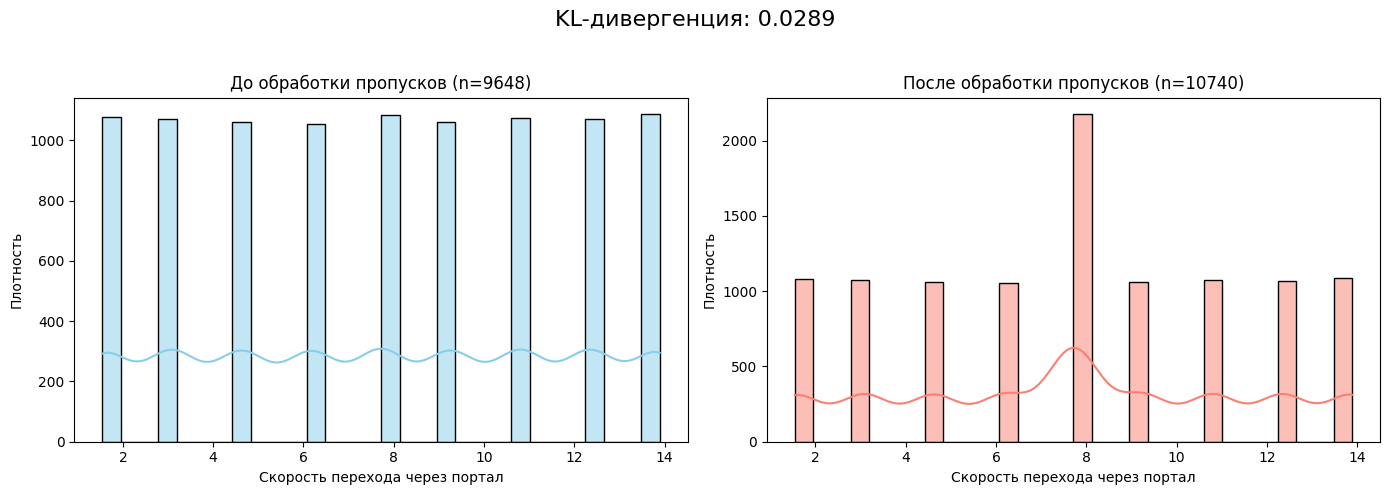

In [ ]:
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train_avg['Скорость перехода через портал'])

Сразу видно, что базовое распределение является равномерным, и замена пропущенных значений средник привела к изменения распределения.

Рассмотрим заполнение пропущенных значений `медианой`.

In [ ]:
X_train_median = X_train.copy()
X_train_median

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Тип Вектора Мощи закодированный
5388,7.148,NaN,38997.064,280.444740,9121.068,332.380,332.380,839.126,736,2.979,15.755,45.060,0.892,0.973,Сильный,4
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,Слабый,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,Сильный,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,Сильный,4
4203,1.138,NaN,353.516,140.504380,6697.654,7.045,7.045,447.407,736,1.097,5.829,9.214,0.074,0.967,Слабый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,Сильный,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,Выше среднего,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,Выше среднего,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,Ниже среднего,2


In [ ]:
median_value = X_train_median['Скорость перехода через портал'].median()
X_train_median['Скорость перехода через портал'] = X_train_median['Скорость перехода через портал'].fillna(median_value)

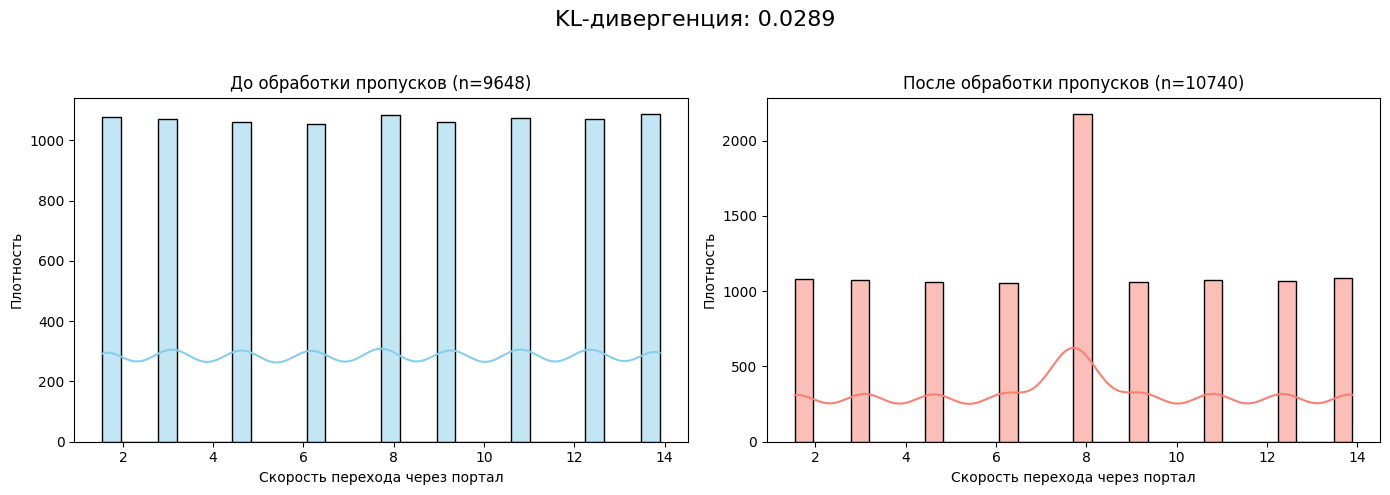

In [ ]:
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train_median['Скорость перехода через портал'])

После заполнения медианой мы получили тот же самый результат, т.к. медиана и среднее были приблизительно равны.

При рассмотрении статистического заполнения, можно взять как заполнение средним, так и заполнение медианой, посмотрим, что получиться после заполнения пропущенных значений при помощи машинных методов.

### 1.1.5.1.2. <a id='toc1_1_5_1_2_'></a>[Заполнение пропущенных значений машинными подходами](#toc0_)

`Машинный подход`

Рассмотрим три варианта заполнения: `MICE`, `IterativeImputer`, `KNNImputer `. Для оценки качества этих подходов будет использована метрика `NRMSE`, с целью проверки корректности заполнения.

`NRMSE` (normalized root mean squared error) — нормализованная среднеквадратическая ошибка. Это относительная мера ошибок прогнозирования, которая позволяет сравнивать производительность моделей на разных наборах данных или в разных масштабах.

`NRMSE` вычисляется путём деления `RMSE` (среднеквадратической ошибки) на диапазон целевой переменной (разница между максимальным и минимальным значениями).

Чем меньше значение `NRMSE`, тем выше точность модели. Обычно хорошими считаются значения ниже `10%`, а показатели ниже `5%` указывают на отличную производительность.

$$NRMSE = \frac{RMSE}{X_{max} - X_{min}}$$
$$NRMSE = \frac{\sqrt(\frac{1}{N}*\sum(y_{i}-\widehat y_{i})^2}{X_{max} - X_{min}}$$

где:
- N - размер выборки;
- $y_{i}$ - реальное значение;
- $\widehat y_{i}$ - предсказанное значение;
- $X_{min}$ - минимальное значение в выборке;
- $X_{max}$ - максимальное значение в выборке.

Создам функцию, которая будет вычислять метрику `NRMSE`. 

In [ ]:
from sklearn.metrics import mean_squared_error

def calculate_nrmse(original, imputed, mask):
    """
    Вычисляет Normalized Root Mean Square Error (NRMSE) для оценки качества импутации.
    
    Parameters:
    -----------
    original : array-like, pd.Series или pd.DataFrame
        Исходные данные без пропусков (истинные значения)
    imputed : array-like, pd.Series или pd.DataFrame  
        Данные после импутации (предсказанные значения)
    mask : array-like, pd.Series или pd.DataFrame
        Булева маска, где True указывает на позиции искусственных пропусков
        
    Returns:
    --------
    nrmse : float
        Значение NRMSE метрики
        - < 0.1: отличное качество
        - 0.1-0.2: хорошее качество
        - 0.2-0.3: удовлетворительное качество
        - > 0.3: низкое качество
    """
    
    # Преобразуем в numpy arrays для единообразия
    original_array = np.array(original)
    imputed_array = np.array(imputed)
    mask_array = np.array(mask)
    
    # Проверяем размерности
    if original_array.shape != imputed_array.shape:
        raise ValueError("Размерности original и imputed не совпадают")
    
    if original_array.shape != mask_array.shape:
        raise ValueError("Размерности original и mask не совпадают")
    
    # Извлекаем значения, которые были искусственно удалены
    original_masked = original_array[mask_array]
    imputed_masked = imputed_array[mask_array]
    
    # Проверяем, что есть значения для сравнения
    if len(original_masked) == 0:
        raise ValueError("Нет значений для сравнения. Проверьте маску.")
    
    # Вычисляем RMSE 
    rmse = np.sqrt(mean_squared_error(original_masked, imputed_masked))
    
    # Вычисляем диапазон исходных данных для нормализации
    data_range = np.max(original_array) - np.min(original_array)
    
    # Защита от деления на ноль
    try:
        nrmse = rmse / data_range
    except ZeroDivisionError:
        print('Отсутствует диапазон значений')    
    
    return nrmse

Также создам функцию, которая создает искусственные пропуски в датасете для оценки методов машинного обучения. Функция принимает `data` - датасет без пропусков, у которого будем создавать искусственные пропуски, `missing_rate` - процент, сколько будет искусственных пропусков, `missing_type` - тип создания пропусков, принимает два значения, либо `MCAR` - полностью случайные пропуски, либо `MAR` - пропуски зависящие от другого признака, и опционально `dependent_feature` - признак от которого зависят пропуски, только в случае `MAR`.  

In [ ]:
import numpy as np
import pandas as pd

def create_artificial_missing(data, missing_rate=0.1, random_state=SEED, missing_type='MCAR', dependent_feature=None):
    """
    Создает искусственные пропуски в данных для оценки методов импутации.
    
    Parameters:
    -----------
    data : pd.Series или pd.DataFrame
        Исходные данные без пропусков
    missing_rate : float
        Доля пропусков для создания (0-1)
    random_state : int
        Seed для воспроизводимости
    missing_type : str
        Тип пропусков: 
        - 'MCAR' (Missing Completely At Random) - полностью случайные
        - 'MAR' (Missing At Random) - зависящие от другого признака
    dependent_feature : pd.Series
        Признак, от которого зависят пропуски (только для MAR)
        
    Returns:
    --------
    masked_data : same type as input
        Данные с искусственными пропусками
    mask : np.array
        Булева маска, где True - созданные пропуски
    """
    np.random.seed(random_state)
    
    # Создаем копию данных
    masked_data = data.copy()
    
    if missing_type == 'MCAR':
        # Случайные пропуски
        mask = np.random.random(data.shape) < missing_rate
        
    elif missing_type == 'MAR':
        if dependent_feature is None:
            raise ValueError("Для MAR необходимо указать dependent_feature")
        
        # Нормализуем зависимый признак
        dep_normalized = (dependent_feature - dependent_feature.min()) / (dependent_feature.max() - dependent_feature.min())
        # Вероятность пропуска зависит от значений другого признака
        probabilities = dep_normalized * missing_rate * 2
        mask = np.random.random(data.shape) < probabilities
        
    else:
        raise ValueError("missing_type должен быть 'MCAR' или 'MAR'")
    
    # Применяем маску к данным
    if isinstance(masked_data, pd.DataFrame):
        masked_data = masked_data.where(~mask, np.nan)
    else:  # pd.Series
        masked_data[mask] = np.nan
    
    print(f"Создано искусственных пропусков: {mask.sum()} ({mask.sum()/mask.size:.1%})")
    
    return masked_data, mask

### 1.1.5.1.2.1. <a id='toc1_1_5_1_2_1_'></a>[Заполнение пропущенных значений методом MICE](#toc0_)

`MICE` (Multiple Imputation by Chained Equations) — алгоритм машинного обучения, который заполняет пропущенные данные с помощью итерационной серии прогнозирующих моделей. Также называется «множественной импутацией с помощью цепных уравнений».

In [ ]:
from statsmodels.imputation.mice import MICEData

In [ ]:
clean_data = X_train.dropna(subset=['Скорость перехода через портал']).copy()
masked_values, mask = create_artificial_missing(
        clean_data, 
        missing_rate=0.1
    )
clean_data

Создано искусственных пропусков: 15450 (10.0%)


In [ ]:
data_for_mice = clean_data.copy()


In [ ]:
# # Загрузка данных
# # Указываем кодировку файла и сразу задаём корректные имена столбцов
# column_names = [
#     'Вектор Мощи', 'Скорость перехода через портал', 'Приток Силы Потока', 
#     'Ритм магического ядра', 'Поток Энергий', 'Сила Левого Потока', 
#     'Сила Правого Потока', 'Пламя Стихий', 'Температура вдоха Истока', 
#     'Температура выдоха Истока', 'Приток давления Выдоха Истока', 'Давление вдоха Истока', 
#     'Давление выдоха Истока', 'Древний Ветер', 'Печать Чародея', 
#     'Эмульсия Истока', 'Дыхание Истока', 'Гармония Бессмертия', 
#     'Тип Вектора Мощи', 'Номер пометки'
# ]

# df = pd.read_csv(
#     'portal_data.csv',
#     sep='|',
#     na_values=['-'],
#     encoding='cp1251',
#     header=None,
#     names=column_names
# )

# print('Типы данных до преобразования:')
# print(df.info())

# # Удаление столбца с уникальными номерами
# df = df.drop('Номер пометки', axis=1)

# # Удаляем первую строку (шум/NaN по условию) и сбрасываем индекс
# df = df.iloc[1:].reset_index(drop=True)

# # Приведение типов
# for col in df.columns:
#     if df[col].dtype == 'object' and col != 'Тип Вектора Мощи':
#         df[col] = pd.to_numeric(df[col], errors='coerce')

# print('Типы данных после преобразования:')
# print(df.info())

# print('Первые 5 строк данных:')
# df.head()

In [ ]:
# # Базовый EDA: структура, описательная статистика, пропуски и визуализации
# print('Форма датасета:', df.shape)
# print('\nИнформация о датасете:')
# df.info()

# print('\nОписательная статистика (числовые):')
# print(df.describe().T)

# print('\nЧисло пропусков по столбцам:')
# missing_counts = df.isna().sum().sort_values(ascending=False)
# print(missing_counts[missing_counts > 0])

# # Визуализации
# numeric_cols = [c for c in df.columns if df[c].dtype != 'object' and c != 'Тип Вектора Мощи']

# # Гистограммы
# for col in numeric_cols:
#     plt.figure(figsize=(6, 4))
#     sns.histplot(df[col].dropna(), kde=True, log=True, bins=30)
#     plt.title(col)
#     plt.tight_layout()
#     plt.show()

# # Боксплоты
# for col in numeric_cols:
#     plt.figure(figsize=(6, 1.8))
#     sns.boxplot(x=df[col])
#     plt.title(f'Boxplot: {col}')
#     plt.tight_layout()
#     plt.show()

# # Полная тепловая карта корреляций
# if len(numeric_cols) > 1:
#     corr = df[numeric_cols].corr(numeric_only=True)
#     plt.figure(figsize=(max(12, 0.5*len(numeric_cols)), max(10, 0.5*len(numeric_cols))))
#     sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5, square=False)
#     plt.title('Корреляции числовых признаков (полная матрица)')
#     plt.tight_layout()
#     plt.show()


### 2.1.1 Использование формул

In [ ]:
# # Переменная, которая будет в себе содержать те признаки, которые не будут участвовать в прогнозировании
# feature_exclusion = []

Т.к. признаки "Сила левого потока" и "Сила правого потока" и "Приток силы потока" имеют попарную корреляцию равную единице, введем новый признак "Суммарная сила всех потоков". Также у этих признаков отсутствуют пропуски, поэтому можно спокойно применять формулу.

In [ ]:
# df['Суммарная Сила Всех Потоков'] = df['Сила Левого Потока'] + df['Сила Правого Потока'] + df['Приток Силы Потока']
# feature_exclusion.extend(['Сила Левого Потока', 'Сила Правого Потока', 'Приток Силы Потока'])
# df['Суммарная Сила Всех Потоков']

Аналогично признаки "Ритм магического ядра" и "Приток силы потока" имеют корреляцию равную 0.99, введу новый признак "Общая сила ядра".

In [ ]:
# df['Общая Сила Ядра'] = df['Ритм магического ядра'] * df['Приток Силы Потока']
# feature_exclusion.append('Ритм магического ядра')
# df['Общая Сила Ядра']

Признаки "Приток давления Выдоха Истока" и "Давление выдоха Истока" имеют корреляцию равную 1, введу новый признак "Общее давление на выходе".

In [ ]:
# df['Общее давление на выходе'] = df['Приток давления Выдоха Истока'] + df['Давление выдоха Истока']
# feature_exclusion.extend(['Приток давления Выдоха истока', 'Давление выдоха Истока'])
# df['Общее давление на выходе']

Признаки "Скорость перехода через портал" и "Эмульсия Истока" имеют корреляцию равную 0.93, введу новую переменную "Магическая производительность"

In [ ]:
# df['Магическая производительность'] = df['Скорость перехода через портал'] / df['Эмульсия Истока']
# feature_exclusion.extend(['Скорость перехода через портал', 'Эмульсия Истока'])
# df['Магическая производительность']

In [ ]:
# corr_2 = df[['Общая Сила Ядра', 'Эмульсия Истока']].corr()
# corr_2

Видим, что признаки "Общая Сила Ядра" и "Эмульсия Истока" имеют высокую корреляцию, введу новый признак "Эффективность Ядра", и посмотрю чему будет составлять корреляция между ним и "Общая Сила Ядра".

In [ ]:
# df['Эффективность Ядра'] = df['Общая Сила Ядра'] / df['Эмульсия Истока']
# corr_3 = df[['Общая Сила Ядра', 'Эффективность Ядра']].corr()
# corr_3

Видим, что корреляция также очень высокая, однако ниже чем, между базовыми признаками, поэтому данный признак будет использоваться в прогнозировании.

### Вывод

Из‑за сильной мультиколлинеарности признаки плохо подходят для линейных моделей без жёсткой регуляризации; предпочтительны деревья решений и градиентный бустинг, устойчивые к коррелированным признакам.

Для подтверждения своих выводов, использую LinearRegression модель как baseline-модель, и как вторую baseline-модель, буду использовать Ridge, т.к. она более устойчива к мультиколлинеарности.

## 2.2 Разделение данных

In [ ]:
# df.drop(columns=feature_exclusion, errors='ignore', inplace=True)
# df

In [ ]:
# numeric_cols = [c for c in df.columns if df[c].dtype != 'object' and c != 'Тип Вектора Мощи']
# if len(numeric_cols) > 1:
#     corr = df[numeric_cols].corr(numeric_only=True)
#     plt.figure(figsize=(max(12, 0.5*len(numeric_cols)), max(10, 0.5*len(numeric_cols))))
#     sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5, square=False)
#     plt.title('Корреляции числовых признаков (полная матрица)')
#     plt.tight_layout()
#     plt.show()

Как итог получилось уменьшить количество мультиколлинеарных признаков.

In [ ]:
# # Определение признаков (X) и целевой переменной (y)
# X = df.drop('Гармония Бессмертия', axis=1)
# y = df['Гармония Бессмертия']

# # Разделение данных на обучающую и тестовую выборки (90/10) т.к. данных не очень много, а 1тыс наблюдений хватит для оценки моделей
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)

# print(f'Размер обучающей выборки: {X_train.shape[0]} наблюдений')
# print(f'Размер тестовой выборки: {X_test.shape[0]} наблюдений')